# Strength Index Harmonization and Elo External Validation

## Purpose

This notebook starts from the previously constructed season-level **Home** and **Away Strength Index** values.

The workflow will eventually be:

$$
(S^{Home}, S^{Away})
\rightarrow
\text{Home/Away harmonization}
\rightarrow
\text{PCA-based unified strength}
\rightarrow
\text{ClubElo external validation}
$$

However, before applying standardization or PCA, we first verify that Home and Away strength actually share a meaningful common structure.

### Stage 1 in this notebook

1. Load the existing Strength Index results.
2. Pair each team-season's Home and Away strength values.
3. Check completeness and uniqueness.
4. Visualize the raw Home–Away relationship.
5. Measure Pearson and Spearman correlation.

Only after these checks will we decide whether a common latent strength direction is justified.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

# -----------------------------
# File configuration
# -----------------------------
STRENGTH_FILE = Path("strength_index_final_results.xlsx")
STRENGTH_SHEET = "Team_Strength_Index"

# If the notebook is executed from a different folder,
# fall back to the uploaded-file location used in this run.
if not STRENGTH_FILE.exists():
    fallback = Path("/mnt/data/strength_index_final_results(1).xlsx")
    if fallback.exists():
        STRENGTH_FILE = fallback

print(f"Using strength file: {STRENGTH_FILE}")


Using strength file: strength_index_final_results.xlsx


## 1. Load the existing Strength Index

The input table should contain one row for every:

$$
(\text{Season},\ \text{Team},\ \text{Venue})
$$

with `Strength_Final` representing the previously constructed venue-specific team strength.


In [2]:
strength = pd.read_excel(
    STRENGTH_FILE,
    sheet_name=STRENGTH_SHEET
)

required_cols = {"Season", "Team", "Venue", "Strength_Final"}
missing_cols = required_cols - set(strength.columns)

if missing_cols:
    raise ValueError(f"Missing required columns: {sorted(missing_cols)}")

print("Raw table shape:", strength.shape)
print("Seasons:", sorted(strength["Season"].astype(str).unique()))
print("Venue labels:", sorted(strength["Venue"].dropna().unique()))

strength.head()


Raw table shape: (200, 10)
Seasons: ['2021-22', '2022-23', '2023-24', '2024-25', '2025-26']
Venue labels: ['Away', 'Home']


,Season,Team,Venue,Shot_Diff,SOT_Rate_Diff,Finishing_Diff,Corners_Diff,Strength_Final,Tier,Rank
0,2021-22,Arsenal,Away,-0.052137,-0.218024,-0.146501,-0.194507,-0.134862,Competitive,6
1,2021-22,Arsenal,Home,0.886679,-0.001952,-0.051989,0.529218,0.281840,Elite,3
2,2021-22,Aston Villa,Away,-0.167772,0.081495,0.107306,-0.103396,0.011685,Competitive,10
3,2021-22,Aston Villa,Home,0.062850,0.167947,0.237220,-0.170707,0.136996,Competitive,15
4,2021-22,Brentford,Away,-0.383557,-0.129069,0.041436,-0.593398,-0.147406,Competitive,11


## 2. Pair Home and Away strength

For each team $i$ in season $t$, we want one two-dimensional observation:

$$
\mathbf{x}_{i,t}
=
\begin{bmatrix}
S^{Home}_{i,t} \\
S^{Away}_{i,t}
\end{bmatrix}.
$$

Before pivoting, we explicitly check that each team-season has **exactly one Home row and one Away row**. This avoids silently averaging or discarding duplicated values.


In [3]:
# Check uniqueness before reshaping
key_counts = (
    strength
    .groupby(["Season", "Team", "Venue"])
    .size()
    .rename("n_rows")
    .reset_index()
)

problem_keys = key_counts[key_counts["n_rows"] != 1]

if len(problem_keys) > 0:
    display(problem_keys)
    raise ValueError(
        "Some Season-Team-Venue combinations do not have exactly one row."
    )

# Reshape to one row per team-season
paired = (
    strength
    .pivot(
        index=["Season", "Team"],
        columns="Venue",
        values="Strength_Final"
    )
    .reset_index()
)

paired.columns.name = None
paired = paired.rename(
    columns={
        "Home": "Home_S",
        "Away": "Away_S"
    }
)

expected_pair_cols = {"Home_S", "Away_S"}
if not expected_pair_cols.issubset(paired.columns):
    raise ValueError(
        f"Expected Home and Away columns after pivot. Found: {paired.columns.tolist()}"
    )

paired = paired[["Season", "Team", "Home_S", "Away_S"]].copy()

print("Paired team-season observations:", len(paired))
paired.head()


Paired team-season observations: 100


,Season,Team,Home_S,Away_S
0,2021-22,Arsenal,0.281840,-0.134862
1,2021-22,Aston Villa,0.136996,0.011685
2,2021-22,Brentford,-0.005392,-0.147406
3,2021-22,Brighton,-0.077576,0.031160
4,2021-22,Burnley,-0.142987,-0.279384


## 3. Completeness check

At this stage, no PCA assumptions are made.

We only verify that every team-season observation has both:

- `Home_S`
- `Away_S`

The number of observations per season is also reported so that changes in league coverage are visible.


In [4]:
missing_summary = paired[["Home_S", "Away_S"]].isna().sum()

print("Missing values:")
print(missing_summary)

if missing_summary.sum() > 0:
    incomplete = paired[
        paired[["Home_S", "Away_S"]].isna().any(axis=1)
    ]
    display(incomplete)
    raise ValueError("Incomplete Home/Away pairs detected.")

season_counts = (
    paired
    .groupby("Season")
    .size()
    .rename("Team_Seasons")
    .reset_index()
)

print("\nTeam-season count by season:")
display(season_counts)

print(f"\nTotal complete observations: {len(paired)}")


Missing values:
Home_S    0
Away_S    0
dtype: int64

Team-season count by season:


,Season,Team_Seasons
0,2021-22,20
1,2022-23,20
2,2023-24,20
3,2024-25,20
4,2025-26,20



Total complete observations: 100


## 4. Raw Home–Away relationship

Before standardization, inspect the original geometry of the two strength measures.

The key question is:

> Do teams that are relatively strong at home also tend to be relatively strong away?

If a clear positive common direction exists, it becomes reasonable to investigate a latent overall-strength axis later.

No PCA is applied in this section.


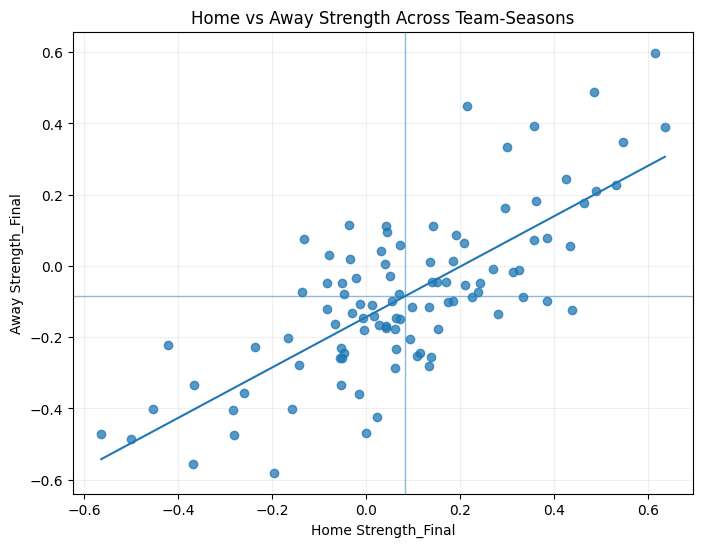

In [5]:
x = paired["Home_S"].to_numpy()
y = paired["Away_S"].to_numpy()

# Simple least-squares reference line for visual inspection only
slope, intercept = np.polyfit(x, y, 1)
x_line = np.linspace(x.min(), x.max(), 200)
y_line = slope * x_line + intercept

fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(x, y, alpha=0.75)
ax.plot(x_line, y_line, linewidth=1.5)

ax.axhline(y.mean(), linewidth=1, alpha=0.5)
ax.axvline(x.mean(), linewidth=1, alpha=0.5)

ax.set_xlabel("Home Strength_Final")
ax.set_ylabel("Away Strength_Final")
ax.set_title("Home vs Away Strength Across Team-Seasons")
ax.grid(alpha=0.2)

plt.show()


## 5. Correlation check

Two complementary measures are reported:

### Pearson correlation

$$
r_P = Corr(S^{Home}, S^{Away})
$$

This measures the strength of the **linear** relationship.

### Spearman correlation

$$
r_S = Corr(rank(S^{Home}), rank(S^{Away}))
$$

This checks whether teams with stronger Home rankings also tend to have stronger Away rankings, without requiring an exactly linear relationship.

A clearly positive relationship supports the existence of a shared Home–Away strength structure, but correlation alone does **not** yet prove that PC1 should be interpreted as overall strength. That interpretation will be checked after PCA.


In [6]:
pearson_r, pearson_p = pearsonr(paired["Home_S"], paired["Away_S"])
spearman_r, spearman_p = spearmanr(paired["Home_S"], paired["Away_S"])

correlation_results = pd.DataFrame(
    {
        "Measure": ["Pearson", "Spearman"],
        "Correlation": [pearson_r, spearman_r],
        "p_value": [pearson_p, spearman_p],
    }
)

display(correlation_results)

print(f"Pearson r  = {pearson_r:.4f}")
print(f"Spearman ρ = {spearman_r:.4f}")


,Measure,Correlation,p_value
0,Pearson,0.750399,2.543421e-19
1,Spearman,0.672799,1.765530e-14


Pearson r  = 0.7504
Spearman ρ = 0.6728


## 6. Optional diagnostic: correlation by season

The pooled five-season relationship is the main structural check for the later harmonization step.

As a diagnostic, we also inspect whether the Home–Away relationship is reasonably persistent across individual seasons. This is not used to fit the PCA yet; it is only a stability check.


In [7]:
season_corr_rows = []

for season, g in paired.groupby("Season", sort=True):
    pr, pp = pearsonr(g["Home_S"], g["Away_S"])
    sr, sp = spearmanr(g["Home_S"], g["Away_S"])

    season_corr_rows.append(
        {
            "Season": season,
            "N": len(g),
            "Pearson_r": pr,
            "Pearson_p": pp,
            "Spearman_rho": sr,
            "Spearman_p": sp,
        }
    )

season_correlations = pd.DataFrame(season_corr_rows)
display(season_correlations)


,Season,N,Pearson_r,Pearson_p,Spearman_rho,Spearman_p
0,2021-22,20,0.797396,0.000025,0.669173,0.001253
1,2022-23,20,0.762600,0.000093,0.783459,0.000044
2,2023-24,20,0.848801,0.000002,0.792481,0.000031
3,2024-25,20,0.782404,0.000046,0.661654,0.001486
4,2025-26,20,0.689829,0.000764,0.533835,0.015337


### Interpretation and decision — Home/Away structure

The pooled five-season results show a clear positive relationship between Home and Away strength, with Pearson correlation around \(0.75\) and Spearman correlation around \(0.67\). The season-by-season diagnostics are also consistently positive.

This supports two conclusions:

1. Home and Away strength are not independent quantities; they share a meaningful common team-strength structure.
2. The relationship is far from perfect, so venue-specific information is still present and should not be discarded.

Therefore, it is reasonable to continue from the original two-dimensional representation

$$
(S^{Home},S^{Away})
$$

toward a common latent-strength coordinate while retaining a separate venue-specific component.


## Checkpoint before PCA

At this point we deliberately stop.

The next stage should only proceed if the observed Home–Away structure is substantively reasonable.

If so, the next steps will be:

$$
(S^{Home},S^{Away})
\rightarrow
(Z_H,Z_A)
\rightarrow
PCA
\rightarrow
(PC1,PC2)
$$

where we will test whether:

- `PC1` can be interpreted as a unified overall-strength axis;
- `PC2` captures Home–Away asymmetry;
- the interpretation is supported by loadings, explained variance, team locations, and later ClubElo validation.

No Elo information is used to construct the PCA axes.


# Stage 2 — Home/Away Standardization and PCA

Stage 1 showed a clear positive relationship between season-level Home and Away strength. We now ask whether the two venue-specific measures can be re-expressed in a common coordinate system.

The goal is **not** to discard venue information. Instead, we rotate the two-dimensional representation

$$
(S^{Home},S^{Away})
$$

into two new coordinates:

$$
(PC1,PC2),
$$

where we will test whether:

- `PC1` represents a common overall-strength direction;
- `PC2` represents Home–Away asymmetry.

At this point, `PC1` is only a **candidate** unified strength measure. It will not be accepted as the final \(S\) until its interpretation is checked and then externally compared with ClubElo.


## 7. Standardize Home and Away strength

Home and Away strength are first placed on a common scale:

$$
Z_H=\frac{S_H-\mu_H}{\sigma_H},
\qquad
Z_A=\frac{S_A-\mu_A}{\sigma_A}.
$$

This gives both variables mean $0$ and variance $1$, so one standard deviation of Home strength has the same scale meaning as one standard deviation of Away strength.

For the **current 2026–27 prior construction**, all five seasons in this notebook are historical information, so the pooled five-season scaler is appropriate for this descriptive harmonization step.

**Important for later backtesting:** when evaluating a past season as if it were unknown, the scaler and PCA basis must be fitted only on the seasons available before that target season, then applied unchanged to the held-out season. Otherwise future information would leak into the state definition.


In [8]:
# Pooled five-season standardization for the current historical harmonization
pca_data = paired.copy()

home_mean = pca_data["Home_S"].mean()
away_mean = pca_data["Away_S"].mean()

# Population standard deviation, consistent with standard z-score scaling
home_sd = pca_data["Home_S"].std(ddof=0)
away_sd = pca_data["Away_S"].std(ddof=0)

if home_sd == 0 or away_sd == 0:
    raise ValueError("Home or Away strength has zero standard deviation.")

pca_data["Home_Z"] = (pca_data["Home_S"] - home_mean) / home_sd
pca_data["Away_Z"] = (pca_data["Away_S"] - away_mean) / away_sd

standardization_parameters = pd.DataFrame(
    {
        "Variable": ["Home_S", "Away_S"],
        "Mean": [home_mean, away_mean],
        "Std_ddof0": [home_sd, away_sd],
        "Z_mean_check": [pca_data["Home_Z"].mean(), pca_data["Away_Z"].mean()],
        "Z_variance_check": [
            pca_data["Home_Z"].var(ddof=0),
            pca_data["Away_Z"].var(ddof=0),
        ],
    }
)

display(standardization_parameters)


,Variable,Mean,Std_ddof0,Z_mean_check,Z_variance_check
0,Home_S,0.082490,0.238447,9.325873e-17,1.0
1,Away_S,-0.085445,0.224760,3.552714e-17,1.0


### Geometry after standardization

After standardization, the historical average team profile is located at:

$$
(0,0).
$$

A point such as $$(1.5,0.5)$$ means that the team-season is 1.5 historical standard deviations above average at home and 0.5 above average away.

The following plot shows the same 100 team-season observations on this common scale before any PCA rotation.


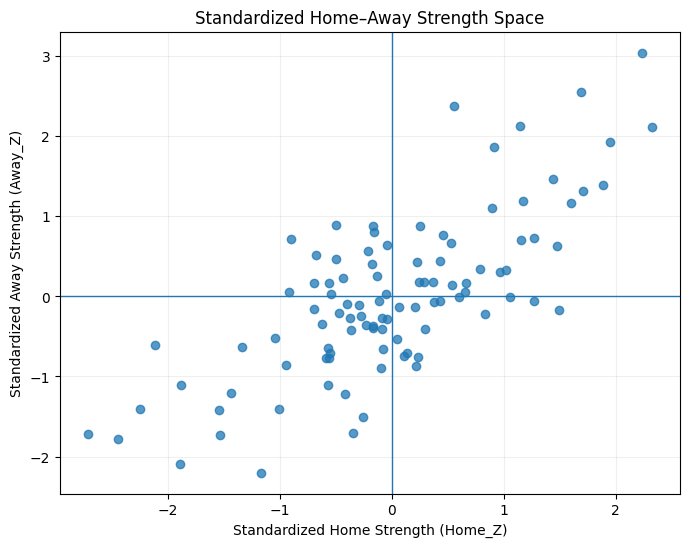

In [9]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(
    pca_data["Home_Z"],
    pca_data["Away_Z"],
    alpha=0.75
)

ax.axhline(0, linewidth=1)
ax.axvline(0, linewidth=1)

ax.set_xlabel("Standardized Home Strength (Home_Z)")
ax.set_ylabel("Standardized Away Strength (Away_Z)")
ax.set_title("Standardized Home–Away Strength Space")
ax.grid(alpha=0.2)

plt.show()


## 8. Principal Component Analysis

PCA searches for orthogonal directions that maximize projected variance.

For the standardized two-variable matrix

$$
X=
\begin{bmatrix}
Z_{H,1} & Z_{A,1}\\
\vdots & \vdots\\
Z_{H,n} & Z_{A,n}
\end{bmatrix},
$$

`PC1` is the direction explaining the largest share of variation in the Home–Away point cloud. `PC2` is perpendicular to PC1 and explains the remaining variation.

Because the sign of an eigenvector is mathematically arbitrary, the signs are oriented here only for interpretation:

- PC1 is oriented so positive scores correspond to jointly stronger Home and Away performance;
- PC2 is oriented so positive scores correspond to relatively stronger Home than Away performance.

Changing an eigenvector's sign does **not** change the PCA solution, explained variance, distances, or rankings up to reversal.


In [10]:
from sklearn.decomposition import PCA

X_z = pca_data[["Home_Z", "Away_Z"]].to_numpy()

pca = PCA(n_components=2)
raw_scores = pca.fit_transform(X_z)

# Copy components/scores so we can orient their signs for interpretation.
components = pca.components_.copy()
scores = raw_scores.copy()

# PC1: orient toward jointly larger Home_Z and Away_Z.
if components[0].sum() < 0:
    components[0] *= -1
    scores[:, 0] *= -1

# PC2: orient so positive means Home is relatively stronger than Away.
if components[1, 0] < 0:
    components[1] *= -1
    scores[:, 1] *= -1

pca_data["PC1_Strength_Candidate"] = scores[:, 0]
pca_data["PC2_Venue_Asymmetry"] = scores[:, 1]

loadings = pd.DataFrame(
    components.T,
    index=["Home_Z", "Away_Z"],
    columns=["PC1", "PC2"]
)

explained_variance = pd.DataFrame(
    {
        "Component": ["PC1", "PC2"],
        "Explained_Variance_Ratio": pca.explained_variance_ratio_,
        "Explained_Percent": 100 * pca.explained_variance_ratio_,
    }
)

print("PCA loadings:")
display(loadings)

print("\nExplained variance:")
display(explained_variance)


PCA loadings:


,PC1,PC2
Home_Z,0.707107,0.707107
Away_Z,0.707107,-0.707107



Explained variance:


,Component,Explained_Variance_Ratio,Explained_Percent
0,PC1,0.875199,87.519941
1,PC2,0.124801,12.480059


## 9. Analytical check for the two-variable case

Because both variables have been standardized, their correlation matrix has the form

$$
R=
\begin{bmatrix}
1&r\\
r&1
\end{bmatrix}.
$$

For positive $r$, its eigenvectors are:

$$
\frac{1}{\sqrt{2}}
\begin{bmatrix}
1\\
1
\end{bmatrix},
\qquad
\frac{1}{\sqrt{2}}
\begin{bmatrix}
1\\
-1
\end{bmatrix}.
$$

Therefore, in this special two-variable standardized case, PCA should be very close to:

$$
PC1=\frac{Z_H+Z_A}{\sqrt{2}},
\qquad
PC2=\frac{Z_H-Z_A}{\sqrt{2}}.
$$

This is useful because the PCA result becomes completely interpretable rather than a black-box transformation.


In [11]:
r_ha = pca_data[["Home_Z", "Away_Z"]].corr().iloc[0, 1]

theoretical_pc1_share = (1 + r_ha) / 2
theoretical_pc2_share = (1 - r_ha) / 2

analytical_check = pd.DataFrame(
    {
        "Quantity": [
            "Home–Away correlation r",
            "Theoretical PC1 explained share",
            "Observed PC1 explained share",
            "Theoretical PC2 explained share",
            "Observed PC2 explained share",
        ],
        "Value": [
            r_ha,
            theoretical_pc1_share,
            pca.explained_variance_ratio_[0],
            theoretical_pc2_share,
            pca.explained_variance_ratio_[1],
        ],
    }
)

display(analytical_check)

# Numerical equivalence check
pc1_formula = (pca_data["Home_Z"] + pca_data["Away_Z"]) / np.sqrt(2)
pc2_formula = (pca_data["Home_Z"] - pca_data["Away_Z"]) / np.sqrt(2)

print(
    "Max |PCA PC1 - analytical PC1|:",
    np.max(np.abs(pca_data["PC1_Strength_Candidate"] - pc1_formula))
)
print(
    "Max |PCA PC2 - analytical PC2|:",
    np.max(np.abs(pca_data["PC2_Venue_Asymmetry"] - pc2_formula))
)


,Quantity,Value
0,Home–Away correlation r,0.750399
1,Theoretical PC1 explained share,0.875199
2,Observed PC1 explained share,0.875199
3,Theoretical PC2 explained share,0.124801
4,Observed PC2 explained share,0.124801


Max |PCA PC1 - analytical PC1|: 4.440892098500626e-16
Max |PCA PC2 - analytical PC2|: 1.6653345369377348e-16


## 10. Visualize the PCA axes in the standardized Home–Away plane

The plot below keeps the original standardized Home/Away axes and overlays the two PCA directions.

If the interpretation is sensible:

- the PC1 direction should run from jointly weak Home/Away performance toward jointly strong Home/Away performance;
- the PC2 direction should separate relatively Home-dominant profiles from relatively Away-dominant profiles.


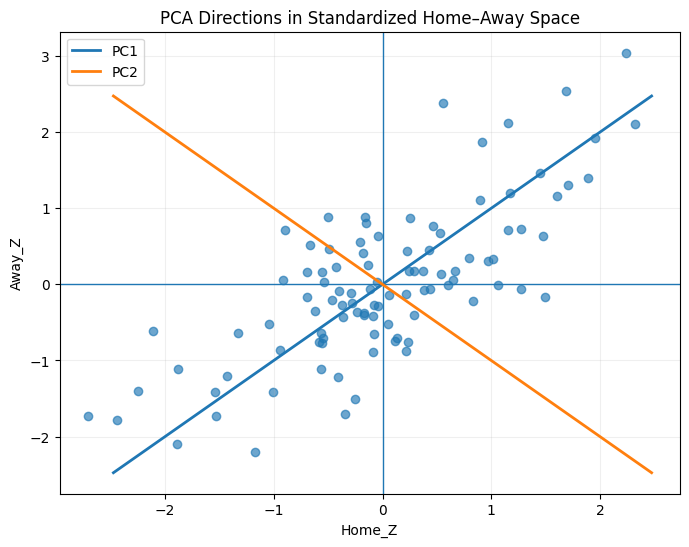

In [12]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(
    pca_data["Home_Z"],
    pca_data["Away_Z"],
    alpha=0.65
)

ax.axhline(0, linewidth=1)
ax.axvline(0, linewidth=1)

# Draw PC axes across the observed standardized range.
axis_length = max(
    pca_data["Home_Z"].abs().max(),
    pca_data["Away_Z"].abs().max()
) * 1.15

for component, label in zip(components, ["PC1", "PC2"]):
    t = np.array([-axis_length, axis_length])
    ax.plot(
        t * component[0],
        t * component[1],
        linewidth=2,
        label=label
    )

ax.set_xlabel("Home_Z")
ax.set_ylabel("Away_Z")
ax.set_title("PCA Directions in Standardized Home–Away Space")
ax.legend()
ax.grid(alpha=0.2)

plt.show()


## 11. Inspect the candidate coordinates

We now retain both PCA scores:

- `PC1_Strength_Candidate`: candidate one-dimensional overall strength;
- `PC2_Venue_Asymmetry`: Home–Away structural imbalance.

A positive PC2 means the team's standardized Home strength is relatively higher than its standardized Away strength. A negative PC2 means the reverse.

The second component is **not discarded**. Even if PC1 later becomes the scalar $S$ used for the Bayesian prior mean, PC2 can remain available as a venue-specific structural variable for later match prediction.


In [13]:
candidate_scores = pca_data[
    [
        "Season",
        "Team",
        "Home_S",
        "Away_S",
        "Home_Z",
        "Away_Z",
        "PC1_Strength_Candidate",
        "PC2_Venue_Asymmetry",
    ]
].copy()

print("2025-26 teams ordered by candidate PC1 strength:")
display(
    candidate_scores[
        candidate_scores["Season"].astype(str).eq("2025-26")
    ]
    .sort_values("PC1_Strength_Candidate", ascending=False)
    .reset_index(drop=True)
)

print("\nLargest Home/Away asymmetries across all five seasons:")
display(
    candidate_scores
    .assign(
        Abs_PC2=lambda d: d["PC2_Venue_Asymmetry"].abs()
    )
    .sort_values("Abs_PC2", ascending=False)
    .head(12)
    .drop(columns="Abs_PC2")
    .reset_index(drop=True)
)


2025-26 teams ordered by candidate PC1 strength:


,Season,Team,Home_S,Away_S,Home_Z,Away_Z,PC1_Strength_Candidate,PC2_Venue_Asymmetry
0,2025-26,Arsenal,0.532572,0.227943,1.887551,1.394322,2.320635,0.348766
1,2025-26,Man City,0.490205,0.209236,1.709875,1.311091,2.136146,0.281983
2,2025-26,Liverpool,0.208509,0.064876,0.528498,0.668808,0.846623,-0.099214
3,2025-26,Man United,0.271100,-0.007558,0.790989,0.346536,0.804352,0.314276
4,2025-26,Bournemouth,0.185212,0.014820,0.430792,0.446100,0.620056,-0.010824
5,2025-26,Chelsea,0.045295,0.094554,-0.155989,0.800850,0.455985,-0.676588
6,2025-26,Aston Villa,0.185726,-0.098689,0.432950,-0.058924,0.264477,0.347808
7,2025-26,Nott'm Forest,0.040095,0.005746,-0.177796,0.405728,0.161172,-0.412614
8,2025-26,Brighton,0.133132,-0.114566,0.212380,-0.129565,0.058559,0.241792
9,2025-26,Tottenham,-0.132290,0.074227,-0.900748,0.710413,-0.134587,-1.139263



Largest Home/Away asymmetries across all five seasons:


,Season,Team,Home_S,Away_S,Home_Z,Away_Z,PC1_Strength_Candidate,PC2_Venue_Asymmetry
0,2021-22,Chelsea,0.215720,0.449225,0.558740,2.378849,2.077189,-1.287012
1,2022-23,Man United,0.437774,-0.122473,1.489989,-0.164745,0.937089,1.170074
2,2025-26,Tottenham,-0.132290,0.074227,-0.900748,0.710413,-0.134587,-1.139263
3,2024-25,Ipswich,-0.421577,-0.223202,-2.113961,-0.612908,-1.928187,-1.061405
4,2024-25,Crystal Palace,-0.036400,0.113759,-0.498605,0.886299,0.274142,-0.979275
5,2022-23,Nott'm Forest,-0.000177,-0.469518,-0.346691,-1.708815,-1.453462,0.963167
6,2023-24,Newcastle,0.386374,-0.099756,1.274428,-0.063673,0.856133,0.946180
7,2021-22,Everton,0.022657,-0.424876,-0.250928,-1.510193,-1.245301,0.890434
8,2021-22,Brighton,-0.077576,0.031160,-0.671285,0.518797,-0.107825,-0.841515
9,2023-24,Everton,0.133844,-0.280930,0.215366,-0.869748,-0.462718,0.767292


### Interpretation and decision — PCA harmonization

After standardizing Home and Away strength, the two-dimensional PCA produces

$$
PC1 \approx \frac{Z_H+Z_A}{\sqrt{2}},
\qquad
PC2 \approx \frac{Z_H-Z_A}{\sqrt{2}}.
$$

PC1 explains approximately \(87.5\%\) of the joint Home–Away variation, whereas PC2 explains the remaining \(12.5\%\).

The interpretation is therefore:

$$
PC1 \rightarrow \text{common / overall strength candidate},
$$

$$
PC2 \rightarrow \text{Home–Away venue asymmetry}.
$$

Importantly, PCA is **not** being used here to learn an "optimal" unequal weighting between Home and Away. Because both variables were standardized, this special two-variable PCA primarily performs an orthogonal rotation of the coordinate system. Its value is the separation of common strength from venue asymmetry.

At this stage, PC1 is still treated as a **candidate** unified strength measure. External validation is required before promoting it to the final scalar strength \(S\).


# Stage 3 — ClubElo External Validation

The PCA stage produced:

$$
PC1=\text{candidate common strength},
\qquad
PC2=\text{venue asymmetry}.
$$

ClubElo is introduced **only as an external benchmark**. It is not used to fit the Strength Index, standardize Home/Away strength, determine the PCA axes, or construct the later Bayesian prior.

### Revised validation design

The **primary** Elo benchmark is now based on the actual Premier League match dates used by the project.

For team $i$, season $t$, and league match $m$, the Elo observation is the value whose ClubElo interval satisfies

$$
From \le Date_{i,t,m} \le To.
$$

The team-season benchmark is then

$$
\bar E^{match}_{i,t}
=
\frac{1}{N_{i,t}}
\sum_{m=1}^{N_{i,t}}Elo_i(Date_{i,t,m}).
$$

This gives each league match equal weight and avoids giving additional weight to long calendar periods in which no league match was played.

Two previous summaries are retained only as **robustness checks**:

1. calendar-time weighted season-average Elo;
2. season-end Elo.

ClubElo exits the modeling pipeline after this validation stage.


In [22]:
# -----------------------------
# Stage 3 file configuration
# -----------------------------
ELO_ZIP = Path("data_from_Clubelo.zip")

if not ELO_ZIP.exists():
    fallback = Path("data_from_Clubelo.zip")
    if fallback.exists():
        ELO_ZIP = fallback

if not ELO_ZIP.exists():
    raise FileNotFoundError("ClubElo zip file could not be found.")

# The preferred match source is the already-created team-perspective long table.
MATCH_FILE_CANDIDATES = [
    Path("team_match_long.csv"),
    Path("processed_data/team_match_long.csv"),
    Path("/mnt/data/team_match_long.csv"),
]

# A merged E0 match table can also be used as a fallback and converted to long format.
E0_FILE_CANDIDATES = [
    Path("e0_matches_5seasons.csv"),
    Path("processed_data/e0_matches_5seasons.csv"),
    Path("/mnt/data/e0_matches_5seasons.csv"),
]

MATCH_FILE = next((p for p in MATCH_FILE_CANDIDATES if p.exists()), None)
E0_FILE = next((p for p in E0_FILE_CANDIDATES if p.exists()), None)

print(f"Using ClubElo archive: {ELO_ZIP}")
print(f"team_match_long source: {MATCH_FILE}")
print(f"E0 fallback source: {E0_FILE}")

if MATCH_FILE is None and E0_FILE is None:
    print(
        "\nNOTE: Match-date validation code is ready, but the current runtime "
        "does not contain team_match_long.csv or e0_matches_5seasons.csv. "
        "Place either file beside this notebook (or in processed_data/) and rerun."
    )


Using ClubElo archive: data_from_Clubelo.zip
team_match_long source: team_match_long.csv
E0 fallback source: e0_matches_5seasons.csv


## 12. Read and clean ClubElo

The ClubElo archive contains one CSV per club. Several files begin directly with data instead of a header, so the loader detects and repairs these files automatically.

Only the fields required for date matching and validation are retained. `Rank` is not needed because team ranks can be recomputed from the Elo values.


In [24]:
from pathlib import Path
import io
import zipfile

ELO_COLUMNS = ["Rank", "Club", "Country", "Level", "Elo", "From", "To"]

elo_frames = []
headerless_files = []

with zipfile.ZipFile(ELO_ZIP, "r") as zf:
    for filename in sorted(zf.namelist()):
        if not filename.lower().endswith(".csv"):
            continue

        raw = zf.read(filename)
        text = raw.decode("utf-8-sig", errors="replace")
        first_line = text.splitlines()[0] if text.splitlines() else ""

        if first_line.startswith("Rank,Club,Country,Level,Elo,From,To"):
            df = pd.read_csv(io.BytesIO(raw))
        else:
            headerless_files.append(filename)
            df = pd.read_csv(
                io.BytesIO(raw),
                header=None,
                names=ELO_COLUMNS
            )

        df["Source_File"] = filename
        elo_frames.append(df)

elo_raw = pd.concat(elo_frames, ignore_index=True)

elo_raw["Club"] = elo_raw["Club"].astype(str).str.strip()
elo_raw["Elo"] = pd.to_numeric(elo_raw["Elo"], errors="coerce")
elo_raw["Level"] = pd.to_numeric(elo_raw["Level"], errors="coerce")
elo_raw["From"] = pd.to_datetime(elo_raw["From"], errors="coerce")
elo_raw["To"] = pd.to_datetime(elo_raw["To"], errors="coerce")

elo_raw = (
    elo_raw
    .dropna(subset=["Club", "Elo", "From", "To"])
    .sort_values(["Club", "From", "To"])
    .reset_index(drop=True)
)

print("ClubElo rows loaded:", len(elo_raw))
print("Club files loaded:", elo_raw["Source_File"].nunique())
print("Headerless files repaired:", len(headerless_files))
print("Elo missing values after cleaning:", elo_raw["Elo"].isna().sum())

elo_raw.head()


ClubElo rows loaded: 15652
Club files loaded: 29
Headerless files repaired: 8
Elo missing values after cleaning: 0


,Rank,Club,Country,Level,Elo,From,To,Source_File
0,21.0,Arsenal,ENG,1,1795.333496,2020-12-30,2021-01-02,Arsenal.csv
1,20.0,Arsenal,ENG,1,1802.574707,2021-01-03,2021-01-03,Arsenal.csv
2,21.0,Arsenal,ENG,1,1802.574707,2021-01-04,2021-01-08,Arsenal.csv
3,23.0,Arsenal,ENG,1,1802.574707,2021-01-09,2021-01-14,Arsenal.csv
4,23.0,Arsenal,ENG,1,1798.689819,2021-01-15,2021-01-18,Arsenal.csv


## 13. Load the actual Premier League match dates

The preferred source is `team_match_long.csv`, which already represents every league match from each team's perspective and contains:

- `Season`
- `Date`
- `Team`
- `Opponent`
- `Venue`

Therefore each team-season normally contributes 38 date observations directly.

If only `e0_matches_5seasons.csv` is available, the notebook converts every match into one home-team row and one away-team row before continuing.


In [25]:
def load_team_match_dates(match_file=None, e0_file=None):
    if match_file is not None:
        match_long = pd.read_csv(match_file, encoding="utf-8-sig", low_memory=False)
        required = {"Season", "Date", "Team"}
        missing = required - set(match_long.columns)
        if missing:
            raise ValueError(
                f"team_match_long.csv is missing required columns: {sorted(missing)}"
            )

        match_long = match_long.copy()

    elif e0_file is not None:
        e0 = pd.read_csv(e0_file, encoding="utf-8-sig", low_memory=False)
        required = {"Season", "Date", "HomeTeam", "AwayTeam"}
        missing = required - set(e0.columns)
        if missing:
            raise ValueError(
                f"e0_matches_5seasons.csv is missing required columns: {sorted(missing)}"
            )

        home = e0[["Season", "Date", "HomeTeam", "AwayTeam"]].rename(
            columns={"HomeTeam": "Team", "AwayTeam": "Opponent"}
        )
        home["Venue"] = "Home"

        away = e0[["Season", "Date", "AwayTeam", "HomeTeam"]].rename(
            columns={"AwayTeam": "Team", "HomeTeam": "Opponent"}
        )
        away["Venue"] = "Away"

        match_long = pd.concat([home, away], ignore_index=True)

    else:
        return None

    match_long["Season"] = match_long["Season"].astype(str).str.strip()
    match_long["Team"] = match_long["Team"].astype(str).str.strip()

    # team_match_long.csv uses ISO dates; the E0 fallback normally uses day-first dates.
    parsed_iso = pd.to_datetime(match_long["Date"], format="%Y-%m-%d", errors="coerce")
    parsed_dayfirst = pd.to_datetime(
        match_long.loc[parsed_iso.isna(), "Date"],
        dayfirst=True,
        errors="coerce"
    )
    parsed_iso.loc[parsed_iso.isna()] = parsed_dayfirst
    match_long["Date"] = parsed_iso

    if match_long["Date"].isna().any():
        bad = match_long.loc[
            match_long["Date"].isna(),
            ["Season", "Team", "Date"]
        ]
        raise ValueError(f"Unparseable match dates detected:\n{bad.head(20)}")

    # Keep exactly the seasons and teams represented in the PCA table.
    valid_pairs = candidate_scores[["Season", "Team"]].drop_duplicates()

    match_long = match_long.merge(
        valid_pairs,
        on=["Season", "Team"],
        how="inner",
        validate="many_to_one"
    )

    match_long = (
        match_long
        .sort_values(["Season", "Team", "Date"])
        .reset_index(drop=True)
    )

    return match_long


team_matches = load_team_match_dates(MATCH_FILE, E0_FILE)

if team_matches is not None:
    print("Team-perspective league match rows:", len(team_matches))

    match_count_audit = (
        team_matches
        .groupby(["Season", "Team"])
        .size()
        .rename("League_Matches")
        .reset_index()
    )

    print("\nMatch-count distribution:")
    display(
        match_count_audit["League_Matches"]
        .value_counts()
        .sort_index()
        .rename_axis("League_Matches")
        .reset_index(name="Team_Seasons")
    )

    unusual_match_counts = match_count_audit.loc[
        match_count_audit["League_Matches"] != 38
    ]
    if len(unusual_match_counts):
        print("\nTeam-seasons not containing exactly 38 league matches:")
        display(unusual_match_counts)
else:
    match_count_audit = pd.DataFrame()


Team-perspective league match rows: 3800

Match-count distribution:


C:\Users\TK\AppData\Local\Temp\ipykernel_23172\3685328083.py:42: UserWarning: Parsing dates in %Y/%m/%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  parsed_dayfirst = pd.to_datetime(


,League_Matches,Team_Seasons
0,38,100


## 14. Match each league date to the active ClubElo interval

For every team separately, the notebook performs an as-of match against ClubElo:

1. find the most recent `From` date not later than the league match date;
2. verify that the league match date is also no later than that row's `To`;
3. retain that Elo value only if both conditions hold.

Thus a match on date $d$ receives Elo only when

$$
From \le d \le To.
$$

No interpolation and no forward-filling across an uncovered interval are used.


In [26]:
def attach_match_date_elo(match_table, elo_table):
    if match_table is None:
        return None

    matched_parts = []

    for team, g in match_table.groupby("Team", sort=False):
        g = g.sort_values("Date").copy()

        team_elo = (
            elo_table.loc[
                elo_table["Club"].eq(team),
                ["From", "To", "Elo"]
            ]
            .sort_values("From")
            .copy()
        )

        if team_elo.empty:
            g["Elo_From"] = pd.NaT
            g["Elo_To"] = pd.NaT
            g["Match_Date_Elo"] = np.nan
            g["Elo_Matched"] = False
            matched_parts.append(g)
            continue

        m = pd.merge_asof(
            g,
            team_elo.rename(
                columns={
                    "From": "Elo_From",
                    "To": "Elo_To",
                    "Elo": "Match_Date_Elo",
                }
            ),
            left_on="Date",
            right_on="Elo_From",
            direction="backward",
            allow_exact_matches=True,
        )

        valid_interval = (
            m["Elo_From"].notna()
            & m["Elo_To"].notna()
            & (m["Date"] >= m["Elo_From"])
            & (m["Date"] <= m["Elo_To"])
        )

        m.loc[~valid_interval, "Match_Date_Elo"] = np.nan
        m["Elo_Matched"] = m["Match_Date_Elo"].notna()

        matched_parts.append(m)

    return pd.concat(matched_parts, ignore_index=True)


match_elo = attach_match_date_elo(team_matches, elo_raw)

if match_elo is not None:
    print("League-date observations:", len(match_elo))
    print("Matched Elo observations:", int(match_elo["Elo_Matched"].sum()))
    print("Unmatched Elo observations:", int((~match_elo["Elo_Matched"]).sum()))

    unmatched_preview = match_elo.loc[
        ~match_elo["Elo_Matched"],
        ["Season", "Date", "Team", "Opponent", "Venue"]
    ]

    if len(unmatched_preview):
        print("\nUnmatched date examples:")
        display(unmatched_preview.head(20))


League-date observations: 3800
Matched Elo observations: 3720
Unmatched Elo observations: 80

Unmatched date examples:


,Season,Date,Team,Opponent,Venue
2812,2021-22,2021-08-15,West Ham,Newcastle,Away
2813,2021-22,2021-08-23,West Ham,Leicester,Home
2814,2021-22,2021-08-28,West Ham,Crystal Palace,Home
2815,2021-22,2021-09-11,West Ham,Southampton,Away
2816,2021-22,2021-09-19,West Ham,Man United,Home
2817,2021-22,2021-09-25,West Ham,Leeds,Away
2818,2021-22,2021-10-03,West Ham,Brentford,Home
2819,2021-22,2021-10-17,West Ham,Everton,Away
2820,2021-22,2021-10-24,West Ham,Tottenham,Home
2821,2021-22,2021-10-31,West Ham,Aston Villa,Away


## 15. Build the match-date season-average Elo

For each team-season:

$$
\bar E^{match}_{i,t}
=
\frac{1}{M_{i,t}}
\sum_{m \in \text{matched league dates}} Elo_{i,t,m}.
$$

The notebook also reports:

$$
Coverage_{i,t}
=
\frac{\text{matched league dates}}
{\text{league matches in the dataset}}.
$$

The primary validation uses team-seasons with at least **90% match-date coverage**. This retains cases with a very small amount of missing early Elo history while excluding team-seasons with materially incomplete ClubElo coverage.

No missing match Elo values are imputed.


In [29]:
MIN_MATCH_ELO_COVERAGE = 0.90

if match_elo is not None:
    match_date_elo_season = (
        match_elo
        .groupby(["Season", "Team"], as_index=False)
        .agg(
            Elo_MatchDate_Avg=("Match_Date_Elo", "mean"),
            Matched_Elo_Matches=("Elo_Matched", "sum"),
            League_Matches=("Date", "size"),
        )
    )

    match_date_elo_season["Match_Elo_Coverage"] = (
        match_date_elo_season["Matched_Elo_Matches"]
        / match_date_elo_season["League_Matches"]
    )

    match_date_elo_season["Primary_Elo_Eligible"] = (
        match_date_elo_season["Match_Elo_Coverage"]
        >= MIN_MATCH_ELO_COVERAGE
    )

    print("Match-date Elo coverage audit:")
    display(
        match_date_elo_season
        .sort_values(["Season", "Match_Elo_Coverage", "Team"])
        .reset_index(drop=True)
    )

    print(
        "\nEligible team-seasons:",
        int(match_date_elo_season["Primary_Elo_Eligible"].sum()),
        "/",
        len(match_date_elo_season)
    )
else:
    match_date_elo_season = pd.DataFrame(
        columns=[
            "Season",
            "Team",
            "Elo_MatchDate_Avg",
            "Matched_Elo_Matches",
            "League_Matches",
            "Match_Elo_Coverage",
            "Primary_Elo_Eligible",
        ]
    )
    print(
        "Primary match-date Elo could not be computed in this runtime "
        "because no league match-date file is mounted."
    )


Match-date Elo coverage audit:


,Season,Team,Elo_MatchDate_Avg,Matched_Elo_Matches,League_Matches,Match_Elo_Coverage,Primary_Elo_Eligible
0,2021-22,West Ham,NaN,0,38,0.0,False
1,2021-22,Wolves,NaN,0,38,0.0,False
2,2021-22,Arsenal,1858.026297,38,38,1.0,True
3,2021-22,Aston Villa,1745.086590,38,38,1.0,True
4,2021-22,Brentford,1686.722085,38,38,1.0,True
...,...,...,...,...,...,...,...
95,2025-26,Nott'm Forest,1785.329609,38,38,1.0,True
96,2025-26,Sunderland,1660.672922,38,38,1.0,True
97,2025-26,Tottenham,1799.545535,38,38,1.0,True
98,2025-26,West Ham,1735.216681,38,38,1.0,True



Eligible team-seasons: 98 / 100


### Interpretation and decision — Match-date Elo construction

The primary ClubElo benchmark is constructed from the actual Premier League match dates rather than from an arbitrary calendar-time average.

For each league match, the Elo value is selected only when the match date lies inside the corresponding ClubElo interval:

$$
From \le Date_m \le To.
$$

The team-season benchmark is then the mean of the matched Elo values across league matches:

$$
\bar E^{match}_{i,t}
=
\frac{1}{N_{i,t}}
\sum_m Elo_i(Date_m).
$$

No missing Elo values are interpolated. Coverage is audited explicitly, and team-seasons with materially incomplete ClubElo history are excluded from the primary validation.

This construction aligns the external benchmark with the same domestic-league match occasions that underlie the Strength Index, making it the preferred Elo definition for validation.


## 16. Robustness benchmarks: calendar-time average and season-end Elo

The previous Elo summaries are retained for comparison, but they are no longer the primary benchmark.

### Calendar-time average

Each ClubElo interval is weighted by the number of calendar days for which it overlaps the league-season window.

### Season-end Elo

The Elo value whose interval contains the final league date.

Agreement across all three definitions indicates that the external-validation conclusion is not driven by one arbitrary choice of Elo aggregation.


In [31]:
SEASON_WINDOWS = {
    "2021-22": ("2021-08-13", "2022-05-22"),
    "2022-23": ("2022-08-05", "2023-05-28"),
    "2023-24": ("2023-08-11", "2024-05-19"),
    "2024-25": ("2024-08-16", "2025-05-25"),
    "2025-26": ("2025-08-15", "2026-05-24"),
}


def summarize_calendar_elo(elo_table, team, start_date, end_date):
    start_date = pd.Timestamp(start_date)
    end_date = pd.Timestamp(end_date)

    team_elo = elo_table.loc[elo_table["Club"].eq(team)].copy()

    if team_elo.empty:
        return {
            "Elo_Calendar_Avg": np.nan,
            "Elo_Season_End": np.nan,
            "Calendar_Elo_Coverage": 0.0,
        }

    team_elo["Overlap_Start"] = team_elo["From"].where(
        team_elo["From"] > start_date,
        start_date
    )
    team_elo["Overlap_End"] = team_elo["To"].where(
        team_elo["To"] < end_date,
        end_date
    )
    team_elo["Overlap_Days"] = (
        team_elo["Overlap_End"] - team_elo["Overlap_Start"]
    ).dt.days + 1

    overlap = team_elo.loc[team_elo["Overlap_Days"] > 0].copy()
    season_days = (end_date - start_date).days + 1

    if len(overlap):
        calendar_avg = np.average(
            overlap["Elo"],
            weights=overlap["Overlap_Days"]
        )
        covered_days = overlap["Overlap_Days"].sum()
        coverage = covered_days / season_days
    else:
        calendar_avg = np.nan
        coverage = 0.0

    end_row = team_elo.loc[
        (team_elo["From"] <= end_date)
        & (team_elo["To"] >= end_date)
    ]

    season_end = end_row.iloc[-1]["Elo"] if len(end_row) else np.nan

    return {
        "Elo_Calendar_Avg": calendar_avg,
        "Elo_Season_End": season_end,
        "Calendar_Elo_Coverage": coverage,
    }


robust_rows = []

for _, row in candidate_scores[["Season", "Team"]].drop_duplicates().iterrows():
    season = str(row["Season"])
    team = row["Team"]

    if season not in SEASON_WINDOWS:
        continue

    start_date, end_date = SEASON_WINDOWS[season]
    robust_rows.append(
        {
            "Season": season,
            "Team": team,
            **summarize_calendar_elo(
                elo_raw,
                team,
                start_date,
                end_date
            ),
        }
    )

robust_elo = pd.DataFrame(robust_rows)

display(
    robust_elo.loc[
        robust_elo["Calendar_Elo_Coverage"] < 0.999999
    ]
    .sort_values(["Season", "Calendar_Elo_Coverage"])
    .reset_index(drop=True)
)


,Season,Team,Elo_Calendar_Avg,Elo_Season_End,Calendar_Elo_Coverage
0,2021-22,West Ham,NaN,NaN,0.000000
1,2021-22,Wolves,NaN,NaN,0.000000
2,2022-23,West Ham,1765.292941,1767.353943,0.946128
3,2022-23,Wolves,1711.952757,1716.955161,0.949495


## 17. Merge PCA strength with all Elo benchmarks

The Elo data are merged **after** the PCA coordinates have already been constructed.

Therefore Elo cannot affect the definition of PC1 or PC2.


In [32]:
validation = candidate_scores.merge(
    robust_elo,
    on=["Season", "Team"],
    how="left",
    validate="one_to_one"
)

if len(match_date_elo_season):
    validation = validation.merge(
        match_date_elo_season,
        on=["Season", "Team"],
        how="left",
        validate="one_to_one"
    )
else:
    for col in [
        "Elo_MatchDate_Avg",
        "Matched_Elo_Matches",
        "League_Matches",
        "Match_Elo_Coverage",
        "Primary_Elo_Eligible",
    ]:
        validation[col] = np.nan

print("Validation rows:", len(validation))
display(validation.head())


Validation rows: 100


,Season,Team,Home_S,Away_S,Home_Z,Away_Z,PC1_Strength_Candidate,PC2_Venue_Asymmetry,Elo_Calendar_Avg,Elo_Season_End,Calendar_Elo_Coverage,Elo_MatchDate_Avg,Matched_Elo_Matches,League_Matches,Match_Elo_Coverage,Primary_Elo_Eligible
0,2021-22,Arsenal,0.281840,-0.134862,0.836034,-0.219863,0.435698,0.746632,1857.809743,1846.869629,1.0,1858.026297,38,38,1.0,True
1,2021-22,Aston Villa,0.136996,0.011685,0.228584,0.432151,0.467211,-0.143943,1744.493096,1745.432495,1.0,1745.086590,38,38,1.0,True
2,2021-22,Brentford,-0.005392,-0.147406,-0.368560,-0.275674,-0.455542,-0.065680,1687.602154,1727.171265,1.0,1686.722085,38,38,1.0,True
3,2021-22,Brighton,-0.077576,0.031160,-0.671285,0.518797,-0.107825,-0.841515,1731.966345,1751.484985,1.0,1731.980469,38,38,1.0,True
4,2021-22,Burnley,-0.142987,-0.279384,-0.945606,-0.862871,-1.278786,-0.058503,1692.862675,1694.628906,1.0,1694.930298,38,38,1.0,True


## 18. Validation function

For each season separately, report:

- Pearson correlation;
- Spearman rank correlation;
- mean absolute rank difference.

Per-season validation is primary because it compares the two strength systems inside the same competitive season rather than relying on a pooled five-season correlation.


In [33]:
def validation_summary(
    table,
    elo_column,
    strength_column="PC1_Strength_Candidate",
    eligibility_column=None,
):
    rows = []

    for season, group in table.groupby("Season", sort=True):
        g = group.copy()

        if eligibility_column is not None:
            g = g.loc[g[eligibility_column].fillna(False)]

        g = g.dropna(subset=[strength_column, elo_column]).copy()

        if len(g) < 3:
            continue

        pearson_r, pearson_p = pearsonr(
            g[strength_column],
            g[elo_column]
        )
        spearman_r, spearman_p = spearmanr(
            g[strength_column],
            g[elo_column]
        )

        g["Strength_Rank"] = g[strength_column].rank(
            method="min",
            ascending=False
        )
        g["Elo_Rank"] = g[elo_column].rank(
            method="min",
            ascending=False
        )

        rows.append(
            {
                "Season": season,
                "N": len(g),
                "Pearson_r": pearson_r,
                "Pearson_p": pearson_p,
                "Spearman_rho": spearman_r,
                "Spearman_p": spearman_p,
                "Mean_Abs_Rank_Diff": (
                    g["Strength_Rank"] - g["Elo_Rank"]
                ).abs().mean(),
            }
        )

    return pd.DataFrame(rows)


## 19. Primary external validation: PC1 vs match-date average Elo

This is the main validation result because both quantities summarize the same set of domestic-league match occasions:

$$
PC1_{i,t}
\longleftrightarrow
\bar E^{match}_{i,t}.
$$

Only team-seasons meeting the match-date Elo coverage threshold are included.


In [34]:
if validation["Elo_MatchDate_Avg"].notna().any():
    match_elo_validation = validation_summary(
        validation,
        "Elo_MatchDate_Avg",
        eligibility_column="Primary_Elo_Eligible"
    )
    display(match_elo_validation)
else:
    match_elo_validation = pd.DataFrame()
    print(
        "Match-date validation results are unavailable until "
        "team_match_long.csv or e0_matches_5seasons.csv is supplied."
    )


,Season,N,Pearson_r,Pearson_p,Spearman_rho,Spearman_p,Mean_Abs_Rank_Diff
0,2021-22,18,0.924045,4.380521e-08,0.874097,0.000002,1.666667
1,2022-23,20,0.826924,6.932076e-06,0.831579,0.000006,2.700000
2,2023-24,20,0.883917,2.368231e-07,0.855639,0.000002,2.300000
3,2024-25,20,0.917925,1.188104e-08,0.855639,0.000002,2.200000
4,2025-26,20,0.848222,2.308349e-06,0.828571,0.000006,2.500000


## 20. Robustness checks

Two alternative Elo definitions are now secondary checks:

$$
PC1 \leftrightarrow \text{calendar-time average Elo}
$$

and

$$
PC1 \leftrightarrow \text{season-end Elo}.
$$

They should support the same broad conclusion without defining the primary benchmark.


In [35]:
calendar_elo_validation = validation_summary(
    validation,
    "Elo_Calendar_Avg"
)

end_elo_validation = validation_summary(
    validation,
    "Elo_Season_End"
)

print("Calendar-time average Elo:")
display(calendar_elo_validation)

print("\nSeason-end Elo:")
display(end_elo_validation)


Calendar-time average Elo:


,Season,N,Pearson_r,Pearson_p,Spearman_rho,Spearman_p,Mean_Abs_Rank_Diff
0,2021-22,18,0.921400,5.711801e-08,0.865841,0.000003,1.777778
1,2022-23,20,0.822747,8.453236e-06,0.831579,0.000006,2.700000
2,2023-24,20,0.882115,2.702034e-07,0.854135,0.000002,2.300000
3,2024-25,20,0.918076,1.169268e-08,0.854135,0.000002,2.300000
4,2025-26,20,0.845931,2.618475e-06,0.830075,0.000006,2.500000



Season-end Elo:


,Season,N,Pearson_r,Pearson_p,Spearman_rho,Spearman_p,Mean_Abs_Rank_Diff
0,2021-22,18,0.966913,6.510058e-11,0.929825,2.369256e-08,1.222222
1,2022-23,20,0.906126,3.808178e-08,0.948872,1.882170e-10,1.500000
2,2023-24,20,0.908991,2.912502e-08,0.882707,2.588147e-07,2.100000
3,2024-25,20,0.965719,5.483956e-12,0.933835,1.812687e-09,1.400000
4,2025-26,20,0.930491,2.790021e-09,0.890226,1.466833e-07,2.000000


## 21. Primary scatter plots by season

Each panel below compares PC1 with the match-date average ClubElo.

The plots are generated only when the league match-date file is available.


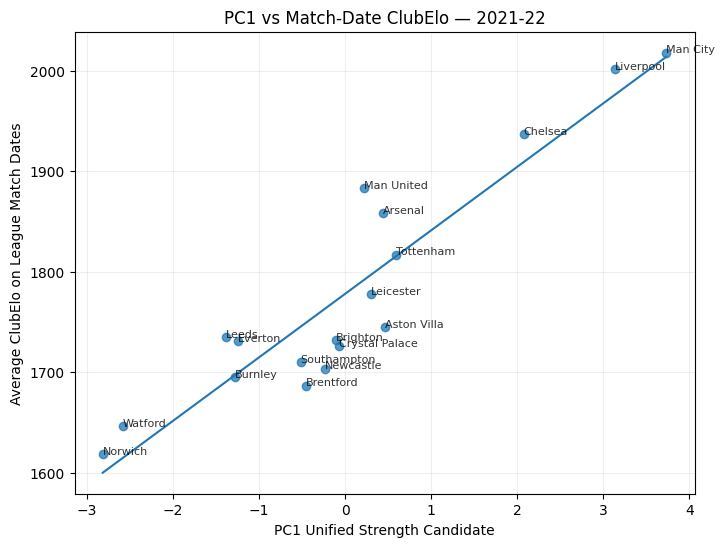

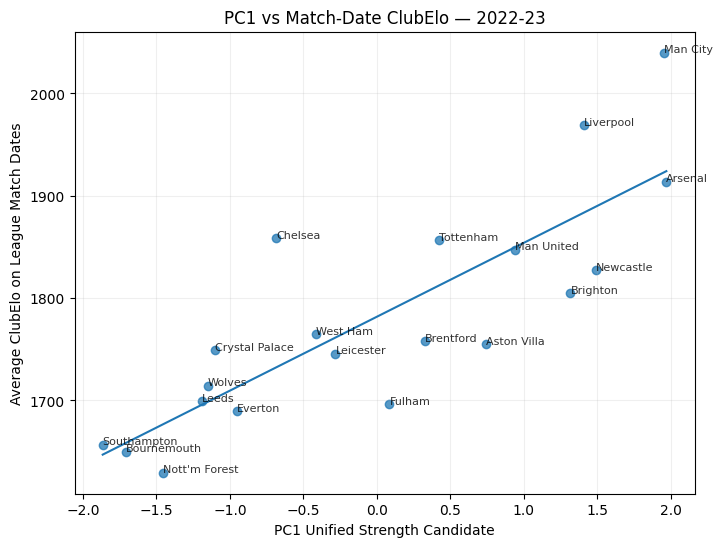

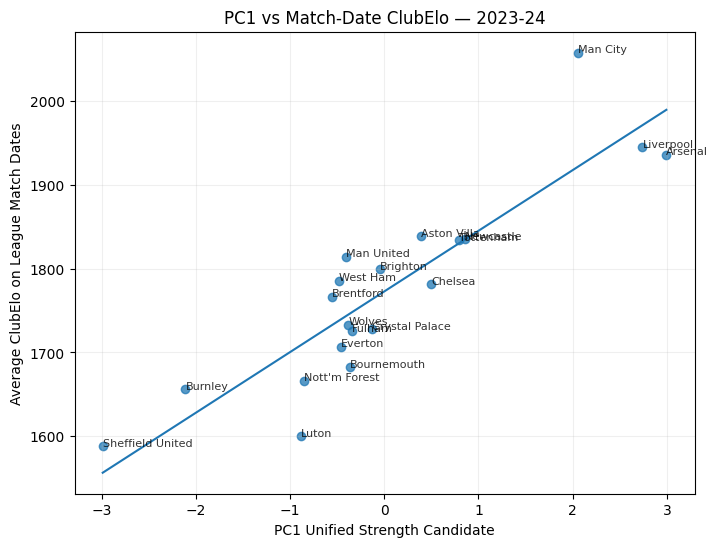

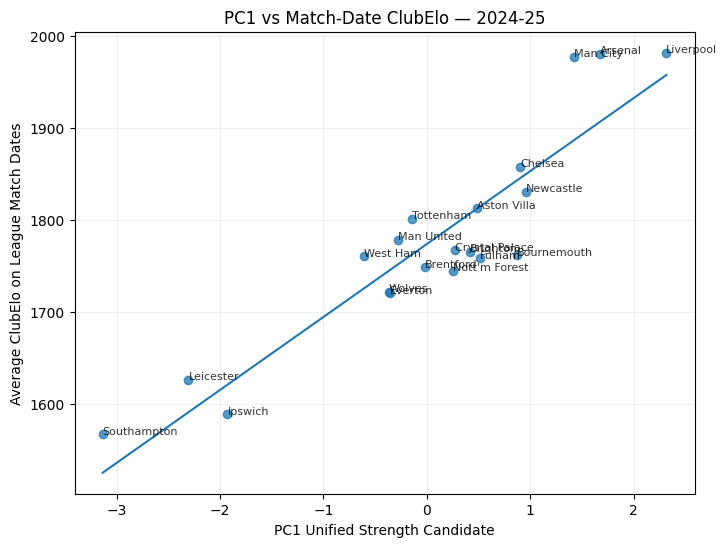

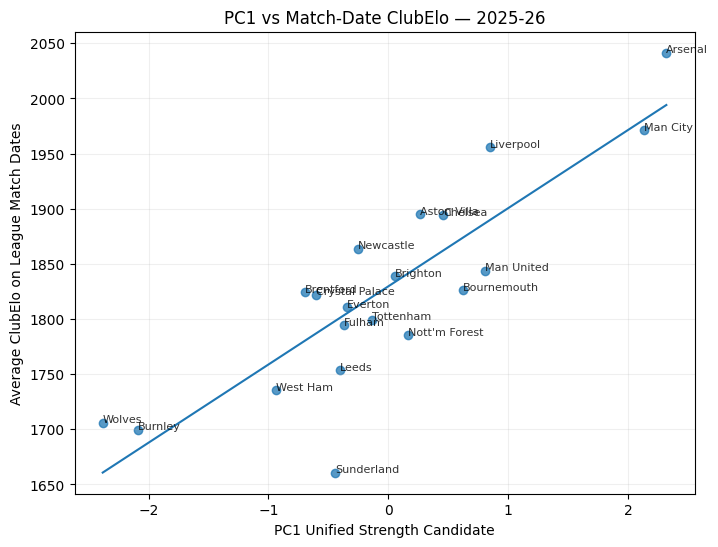

In [36]:
if validation["Elo_MatchDate_Avg"].notna().any():
    for season in sorted(validation["Season"].astype(str).unique()):
        g = validation.loc[
            validation["Season"].astype(str).eq(season)
            & validation["Primary_Elo_Eligible"].fillna(False)
        ].dropna(
            subset=["PC1_Strength_Candidate", "Elo_MatchDate_Avg"]
        ).copy()

        if len(g) < 3:
            continue

        fig, ax = plt.subplots(figsize=(8, 6))

        ax.scatter(
            g["PC1_Strength_Candidate"],
            g["Elo_MatchDate_Avg"],
            alpha=0.75
        )

        slope, intercept = np.polyfit(
            g["PC1_Strength_Candidate"],
            g["Elo_MatchDate_Avg"],
            1
        )

        x_line = np.linspace(
            g["PC1_Strength_Candidate"].min(),
            g["PC1_Strength_Candidate"].max(),
            200
        )

        ax.plot(
            x_line,
            slope * x_line + intercept,
            linewidth=1.5
        )

        for _, r in g.iterrows():
            ax.annotate(
                r["Team"],
                (
                    r["PC1_Strength_Candidate"],
                    r["Elo_MatchDate_Avg"]
                ),
                fontsize=8,
                alpha=0.8
            )

        ax.set_xlabel("PC1 Unified Strength Candidate")
        ax.set_ylabel("Average ClubElo on League Match Dates")
        ax.set_title(f"PC1 vs Match-Date ClubElo — {season}")
        ax.grid(alpha=0.2)

        plt.show()
else:
    print("Primary scatter plots skipped: league match-date source not mounted.")


## 22. Rank consistency for the primary benchmark

Rank differences show individual team-seasons where the Strength Index and ClubElo disagree.

Perfect rank identity is not expected because the two systems deliberately use different information.


In [37]:
if validation["Elo_MatchDate_Avg"].notna().any():
    primary_rank_rows = []

    for season, group in validation.groupby("Season", sort=True):
        g = group.loc[
            group["Primary_Elo_Eligible"].fillna(False)
        ].dropna(
            subset=["PC1_Strength_Candidate", "Elo_MatchDate_Avg"]
        ).copy()

        if len(g) < 3:
            continue

        g["PC1_Rank"] = g["PC1_Strength_Candidate"].rank(
            method="min", ascending=False
        ).astype(int)

        g["MatchDate_Elo_Rank"] = g["Elo_MatchDate_Avg"].rank(
            method="min", ascending=False
        ).astype(int)

        g["Abs_Rank_Difference"] = (
            g["PC1_Rank"] - g["MatchDate_Elo_Rank"]
        ).abs()

        primary_rank_rows.append(
            g[
                [
                    "Season",
                    "Team",
                    "PC1_Strength_Candidate",
                    "Elo_MatchDate_Avg",
                    "Match_Elo_Coverage",
                    "PC1_Rank",
                    "MatchDate_Elo_Rank",
                    "Abs_Rank_Difference",
                ]
            ]
        )

    primary_rank_comparison = pd.concat(
        primary_rank_rows,
        ignore_index=True
    )

    for season in sorted(primary_rank_comparison["Season"].astype(str).unique()):
        print(f"\n{season}")
        display(
            primary_rank_comparison.loc[
                primary_rank_comparison["Season"].astype(str).eq(season)
            ]
            .sort_values("PC1_Rank")
            .reset_index(drop=True)
        )
else:
    primary_rank_comparison = pd.DataFrame()
    print("Primary rank tables skipped: league match-date source not mounted.")



2021-22


,Season,Team,PC1_Strength_Candidate,Elo_MatchDate_Avg,Match_Elo_Coverage,PC1_Rank,MatchDate_Elo_Rank,Abs_Rank_Difference
0,2021-22,Man City,3.733919,2017.915858,1.0,1,1,0
1,2021-22,Liverpool,3.133562,2001.807139,1.0,2,2,0
2,2021-22,Chelsea,2.077189,1936.829333,1.0,3,3,0
3,2021-22,Tottenham,0.592544,1817.061167,1.0,4,6,2
4,2021-22,Aston Villa,0.467211,1745.086590,1.0,5,8,3
5,2021-22,Arsenal,0.435698,1858.026297,1.0,6,5,1
6,2021-22,Leicester,0.300689,1777.985278,1.0,7,7,0
7,2021-22,Man United,0.217385,1883.161098,1.0,8,4,4
8,2021-22,Crystal Palace,-0.077596,1725.760167,1.0,9,12,3
9,2021-22,Brighton,-0.107825,1731.980469,1.0,10,10,0



2022-23


,Season,Team,PC1_Strength_Candidate,Elo_MatchDate_Avg,Match_Elo_Coverage,PC1_Rank,MatchDate_Elo_Rank,Abs_Rank_Difference
0,2022-23,Arsenal,1.970164,1913.686427,1.000000,1,3,2
1,2022-23,Man City,1.954214,2039.795397,1.000000,2,1,1
2,2022-23,Newcastle,1.490336,1827.089632,1.000000,3,7,4
3,2022-23,Liverpool,1.412122,1969.131672,1.000000,4,2,2
4,2022-23,Brighton,1.317773,1805.045738,1.000000,5,8,3
5,2022-23,Man United,0.937089,1847.139192,1.000000,6,6,0
6,2022-23,Aston Villa,0.744841,1755.119054,1.000000,7,11,4
7,2022-23,Tottenham,0.422472,1856.721715,1.000000,8,5,3
8,2022-23,Brentford,0.330011,1757.870406,1.000000,9,10,1
9,2022-23,Fulham,0.085858,1696.324177,1.000000,10,16,6



2023-24


,Season,Team,PC1_Strength_Candidate,Elo_MatchDate_Avg,Match_Elo_Coverage,PC1_Rank,MatchDate_Elo_Rank,Abs_Rank_Difference
0,2023-24,Arsenal,2.993776,1936.323162,1.0,1,3,2
1,2023-24,Liverpool,2.739443,1945.311334,1.0,2,2,0
2,2023-24,Man City,2.054467,2058.130609,1.0,3,1,2
3,2023-24,Newcastle,0.856133,1835.184439,1.0,4,5,1
4,2023-24,Tottenham,0.796792,1833.967301,1.0,5,6,1
5,2023-24,Chelsea,0.497465,1781.502975,1.0,6,10,4
6,2023-24,Aston Villa,0.387883,1838.716315,1.0,7,4,3
7,2023-24,Brighton,-0.049922,1799.310476,1.0,8,8,0
8,2023-24,Crystal Palace,-0.125815,1728.027800,1.0,9,13,4
9,2023-24,Fulham,-0.339692,1725.682023,1.0,10,14,4



2024-25


,Season,Team,PC1_Strength_Candidate,Elo_MatchDate_Avg,Match_Elo_Coverage,PC1_Rank,MatchDate_Elo_Rank,Abs_Rank_Difference
0,2024-25,Liverpool,2.315585,1981.951239,1.0,1,1,0
1,2024-25,Arsenal,1.671571,1981.097624,1.0,2,2,0
2,2024-25,Man City,1.419272,1977.614955,1.0,3,3,0
3,2024-25,Newcastle,0.954054,1830.593512,1.0,4,5,1
4,2024-25,Chelsea,0.899452,1857.828854,1.0,5,4,1
5,2024-25,Bournemouth,0.870553,1761.602112,1.0,6,11,5
6,2024-25,Fulham,0.509260,1758.326227,1.0,7,13,6
7,2024-25,Aston Villa,0.482517,1812.924075,1.0,8,6,2
8,2024-25,Brighton,0.418187,1765.436578,1.0,9,10,1
9,2024-25,Crystal Palace,0.274142,1766.903301,1.0,10,9,1



2025-26


,Season,Team,PC1_Strength_Candidate,Elo_MatchDate_Avg,Match_Elo_Coverage,PC1_Rank,MatchDate_Elo_Rank,Abs_Rank_Difference
0,2025-26,Arsenal,2.320635,2041.398627,1.0,1,1,0
1,2025-26,Man City,2.136146,1971.400651,1.0,2,2,0
2,2025-26,Liverpool,0.846623,1955.573085,1.0,3,3,0
3,2025-26,Man United,0.804352,1843.819281,1.0,4,7,3
4,2025-26,Bournemouth,0.620056,1825.932736,1.0,5,9,4
5,2025-26,Chelsea,0.455985,1894.050601,1.0,6,5,1
6,2025-26,Aston Villa,0.264477,1895.105575,1.0,7,4,3
7,2025-26,Nott'm Forest,0.161172,1785.329609,1.0,8,15,7
8,2025-26,Brighton,0.058559,1838.584958,1.0,9,8,1
9,2025-26,Tottenham,-0.134587,1799.545535,1.0,10,13,3


## 23. Diagnostic: PC2 vs match-date Elo

If PC1 is the common strength coordinate while PC2 mainly captures venue asymmetry, the external strength signal should generally be much stronger in PC1 than in PC2.

This is a diagnostic rather than a requirement that PC2 correlation must be exactly zero.


In [38]:
if validation["Elo_MatchDate_Avg"].notna().any():
    pc2_match_elo_validation = validation_summary(
        validation,
        "Elo_MatchDate_Avg",
        strength_column="PC2_Venue_Asymmetry",
        eligibility_column="Primary_Elo_Eligible"
    )

    display(
        pc2_match_elo_validation[
            ["Season", "N", "Pearson_r", "Spearman_rho"]
        ]
    )
else:
    pc2_match_elo_validation = pd.DataFrame()
    print("PC2 diagnostic skipped: league match-date source not mounted.")


,Season,N,Pearson_r,Spearman_rho
0,2021-22,18,-0.159253,-0.036120
1,2022-23,20,-0.037591,0.022556
2,2023-24,20,0.043095,0.070677
3,2024-25,20,0.279535,0.345865
4,2025-26,20,-0.124546,-0.159398


### Interpretation and decision — External validation

Across the five seasons, PC1 shows strong positive agreement with the match-date ClubElo benchmark. The per-season Pearson correlations are approximately in the \(0.83\)–\(0.92\) range, while the corresponding Spearman correlations also remain consistently high.

The two robustness definitions — calendar-time average Elo and season-end Elo — support the same broad conclusion.

In contrast, PC2 has a much weaker and less stable relationship with ClubElo. This difference is important: the external overall-strength signal is concentrated primarily in PC1 rather than in the venue-asymmetry direction.

Taken together, the evidence supports the interpretation

$$
\boxed{PC1 \rightarrow \text{Unified Overall Strength}}
$$

and

$$
\boxed{PC2 \rightarrow \text{Venue Asymmetry}}.
$$

The two systems are not expected to produce identical rankings because the Strength Index and ClubElo are independently constructed and use different information. The purpose of the validation is structural agreement, not numerical replication.


## 24. External-validation summary

The preferred evidence hierarchy is now:

1. **Primary:** PC1 vs average Elo on actual league match dates;
2. **Robustness:** PC1 vs calendar-time average Elo;
3. **Robustness:** PC1 vs season-end Elo.

If the primary and robustness results all show strong, stable positive agreement, PC1 can be promoted from a candidate coordinate to the project's unified scalar strength:

$$
\boxed{S_{i,t}=PC1_{i,t}}.
$$

PC2 remains separately available as a venue-asymmetry coordinate.

ClubElo is not carried into the Bayesian prior.


In [39]:
summary_parts = []

if len(match_elo_validation):
    primary = match_elo_validation[
        ["Season", "N", "Pearson_r", "Spearman_rho", "Mean_Abs_Rank_Diff"]
    ].rename(
        columns={
            "N": "N_MatchDate",
            "Pearson_r": "Pearson_MatchDate",
            "Spearman_rho": "Spearman_MatchDate",
            "Mean_Abs_Rank_Diff": "Rank_MAE_MatchDate",
        }
    )
    summary_parts.append(primary)

calendar_part = calendar_elo_validation[
    ["Season", "N", "Pearson_r", "Spearman_rho", "Mean_Abs_Rank_Diff"]
].rename(
    columns={
        "N": "N_Calendar",
        "Pearson_r": "Pearson_Calendar",
        "Spearman_rho": "Spearman_Calendar",
        "Mean_Abs_Rank_Diff": "Rank_MAE_Calendar",
    }
)

end_part = end_elo_validation[
    ["Season", "N", "Pearson_r", "Spearman_rho", "Mean_Abs_Rank_Diff"]
].rename(
    columns={
        "N": "N_End",
        "Pearson_r": "Pearson_End",
        "Spearman_rho": "Spearman_End",
        "Mean_Abs_Rank_Diff": "Rank_MAE_End",
    }
)

summary_parts.extend([calendar_part, end_part])

external_validation_summary = summary_parts[0]
for part in summary_parts[1:]:
    external_validation_summary = external_validation_summary.merge(
        part,
        on="Season",
        how="outer"
    )

display(external_validation_summary)

if len(match_elo_validation):
    print(
        "Median Pearson vs match-date Elo:",
        f"{match_elo_validation['Pearson_r'].median():.4f}"
    )
    print(
        "Median Spearman vs match-date Elo:",
        f"{match_elo_validation['Spearman_rho'].median():.4f}"
    )

print(
    "Median Pearson vs calendar-average Elo:",
    f"{calendar_elo_validation['Pearson_r'].median():.4f}"
)
print(
    "Median Pearson vs season-end Elo:",
    f"{end_elo_validation['Pearson_r'].median():.4f}"
)


,Season,N_MatchDate,Pearson_MatchDate,Spearman_MatchDate,Rank_MAE_MatchDate,N_Calendar,Pearson_Calendar,Spearman_Calendar,Rank_MAE_Calendar,N_End,Pearson_End,Spearman_End,Rank_MAE_End
0,2021-22,18,0.924045,0.874097,1.666667,18,0.921400,0.865841,1.777778,18,0.966913,0.929825,1.222222
1,2022-23,20,0.826924,0.831579,2.700000,20,0.822747,0.831579,2.700000,20,0.906126,0.948872,1.500000
2,2023-24,20,0.883917,0.855639,2.300000,20,0.882115,0.854135,2.300000,20,0.908991,0.882707,2.100000
3,2024-25,20,0.917925,0.855639,2.200000,20,0.918076,0.854135,2.300000,20,0.965719,0.933835,1.400000
4,2025-26,20,0.848222,0.828571,2.500000,20,0.845931,0.830075,2.500000,20,0.930491,0.890226,2.000000


Median Pearson vs match-date Elo: 0.8839
Median Spearman vs match-date Elo: 0.8556
Median Pearson vs calendar-average Elo: 0.8821
Median Pearson vs season-end Elo: 0.9305


# Overall Conclusion

This notebook began with separate season-level Home and Away Strength Index values and asked whether they could be represented by a single overall team-strength coordinate without discarding venue-specific structure.

The analysis produced the following chain of evidence:

$$
(S^{Home},S^{Away})
\rightarrow
(Z_H,Z_A)
\rightarrow
(PC1,PC2)
$$

with:

$$
PC1=\text{common strength direction},
\qquad
PC2=\text{venue-asymmetry direction}.
$$

The Home–Away correlation confirms that a shared strength structure exists, while PCA shows that the common direction explains most of the joint variation. ClubElo then provides an independent external benchmark and shows strong season-by-season agreement with PC1, whereas PC2 carries substantially less overall-strength signal.

Therefore, the project now defines

$$
\boxed{
S_{i,t}=PC1_{i,t}
}
$$

as the **Unified Team Strength** for team \(i\) in season \(t\).

The second coordinate,

$$
\boxed{
V_{i,t}=PC2_{i,t},
}
$$

is retained separately as a measure of Home–Away asymmetry and may later be used when modeling venue-specific match performance.

ClubElo serves only as an external validation benchmark and exits the modeling pipeline at this point. It is **not** included in the Bayesian prior.

The next modeling stage is therefore to construct a preseason Bayesian prior from historical unified strength values:

$$
S_{i,t-1},S_{i,t-2},\ldots
\rightarrow
\mu_{i,0}
$$

followed by the prior uncertainty term

$$
\sigma_{i,0}^{2},
$$

so that the initial latent team strength can be represented as

$$
\theta_{i,0}
\sim
\mathcal{N}(\mu_{i,0},\sigma_{i,0}^{2}).
$$


In [40]:
# ============================================================
# Export unified strength for Bayesian prior modeling
# ============================================================

bayesian_input = candidate_scores[
    [
        "Season",
        "Team",
        "Home_S",
        "Away_S",
        "PC1_Strength_Candidate",
        "PC2_Venue_Asymmetry",
    ]
].copy()

bayesian_input = bayesian_input.rename(
    columns={
        "PC1_Strength_Candidate": "S",
        "PC2_Venue_Asymmetry": "V",
    }
)

# Basic audit
print("Shape:", bayesian_input.shape)
print("Missing values:")
print(bayesian_input.isna().sum())

display(bayesian_input.head())

# Export
bayesian_input.to_csv(
    "bayesian_strength_input.csv",
    index=False
)

print("\nSaved: bayesian_strength_input.csv")

Shape: (100, 6)
Missing values:
Season    0
Team      0
Home_S    0
Away_S    0
S         0
V         0
dtype: int64


,Season,Team,Home_S,Away_S,S,V
0,2021-22,Arsenal,0.281840,-0.134862,0.435698,0.746632
1,2021-22,Aston Villa,0.136996,0.011685,0.467211,-0.143943
2,2021-22,Brentford,-0.005392,-0.147406,-0.455542,-0.065680
3,2021-22,Brighton,-0.077576,0.031160,-0.107825,-0.841515
4,2021-22,Burnley,-0.142987,-0.279384,-1.278786,-0.058503



Saved: bayesian_strength_input.csv


In [41]:
strength_unified = candidate_scores[
    [
        "Season",
        "Team",
        "PC1_Strength_Candidate"
    ]
].copy()

strength_unified = strength_unified.rename(
    columns={"PC1_Strength_Candidate": "S"}
)

strength_unified.to_excel(
    "unified_strength_index.xlsx",
    index=False
)

strength_unified.head()

,Season,Team,S
0,2021-22,Arsenal,0.435698
1,2021-22,Aston Villa,0.467211
2,2021-22,Brentford,-0.455542
3,2021-22,Brighton,-0.107825
4,2021-22,Burnley,-1.278786
